# 03 · Supervised models: can we predict excellence before tasting?

Three model families are compared on the same split, with the same preprocessing pipeline and the same evaluation protocol (`coffee_quality.evaluation`):

1. **out-of-fold probabilities** on the training split (5-fold stratified CV, nested when hyper-parameters are tuned);
2. the decision **threshold** is the one maximising F1 on those out-of-fold probabilities — the test labels are never consulted;
3. refit on the full training split, predict the untouched **test split** (248 lots, 21 excellent);
4. **AUPRC** (average precision) as headline metric, plus F1 / precision / recall at the chosen threshold, with 95% bootstrap intervals.

With only 21 positives in the test split, point estimates are noisy; the out-of-fold AUPRC (82 positives) is reported next to them as a second opinion.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from coffee_quality import config as C
from coffee_quality import data, eda, plotting as P

P.set_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
import time
from coffee_quality import evaluation as E
from coffee_quality.models import boosting, forest, logistic

df = data.load_clean()
X, y = data.make_model_matrix(df)
X_train, X_test, y_train, y_test = data.stratified_split(X, y)
print(f"train: {len(y_train)} lots, {y_train.sum()} excellent | test: {len(y_test)} lots, {y_test.sum()} excellent")

results = {}
def run(name, estimator, **kw):
    t = time.time()
    results[name] = E.evaluate(name, estimator, X_train, y_train, X_test, y_test, n_boot=500, **kw)
    m = results[name].metrics
    print(f"{name:<30} AUPRC={m['auprc']:.3f}  F1={m['f1']:.3f}  ROC AUC={m['roc_auc']:.3f}  threshold={results[name].threshold:.2f}  ({time.time()-t:.0f}s)")

train: 992 lots, 82 excellent | test: 248 lots, 21 excellent


## 1. Logistic regression

The interpretable baseline. Four variants, all class-weighted:

* **unpenalised** — one reference level dropped per categorical variable (Caturra, washed, green, Central/North America);
* **unpenalised + RFECV** — recursive feature elimination scored on average precision;
* **L2** and **L1** — penalty strength tuned by an inner grid search (30 values of *C*), all dummies kept.

In [2]:
for name, est in logistic.all_models().items():
    run(name, est)

LogReg (unpenalised)           AUPRC=0.327  F1=0.400  ROC AUC=0.742  threshold=0.75  (3s)


LogReg (unpenalised + RFECV)   AUPRC=0.340  F1=0.339  ROC AUC=0.743  threshold=0.62  (5s)


LogReg L2                      AUPRC=0.322  F1=0.348  ROC AUC=0.754  threshold=0.68  (17s)


LogReg L1                      AUPRC=0.317  F1=0.320  ROC AUC=0.767  threshold=0.63  (21s)


,LogReg (unpenalised),LogReg (unpenalised + RFECV),LogReg L2,LogReg L1
Variety_Yellow Bourbon,-6.398,-6.727,-0.231,0.000
Variety_Mundo Novo,-4.827,-5.179,-0.194,0.000
Processing.Method_Semi-washed,1.679,1.638,0.254,0.000
Processing.Method_Natural,1.480,1.471,0.424,0.228
Variety_Typica,-1.437,-1.408,-0.566,-0.944
MacroArea_Africa,1.093,1.071,0.661,1.118
MacroArea_Maritime Asia/Pacific,0.997,1.024,0.447,0.886
Processing.Method_Honey,0.974,0.937,0.022,0.000
Processing.Method_Washed,NaN,NaN,-0.635,-0.897
MacroArea_Mainland Asia,-0.777,-0.759,-0.288,0.000


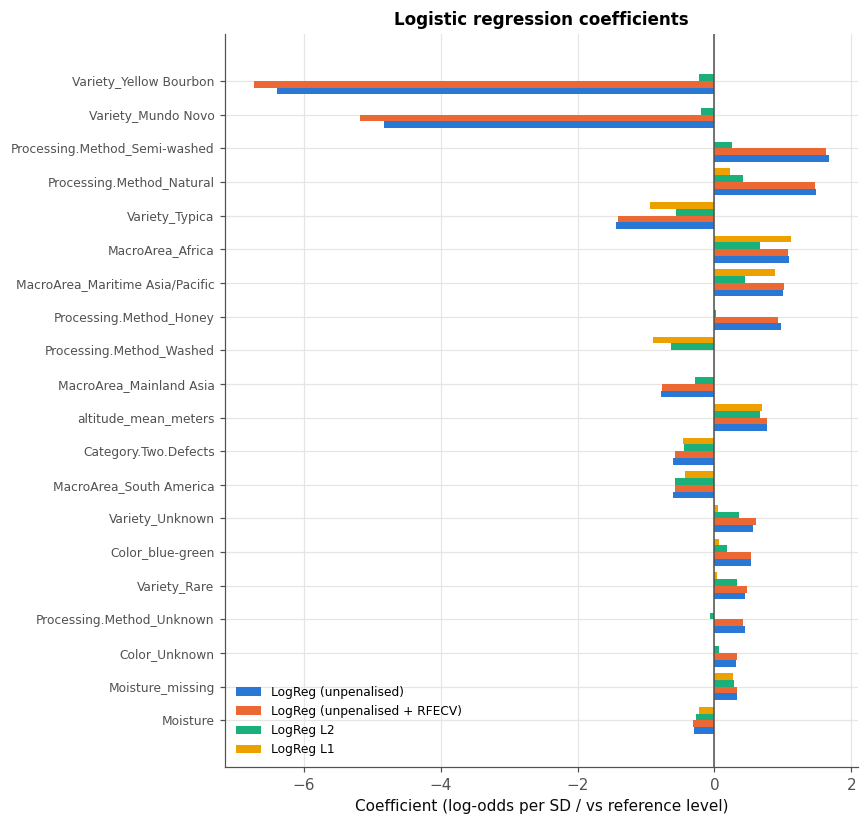

In [3]:
coef = logistic.coefficient_table({k: v for k, v in results.items() if k.startswith("LogReg")})
P.plot_coefficients(coef);
coef.round(3).head(15)

The four variants agree on the story: **altitude up, defects and moisture down** raise the odds of excellence; African and Maritime-Asia/Pacific origins and natural/semi-washed processing add to it; South-American origin and the Typica variety subtract. The two huge negative coefficients (Yellow Bourbon, Mundo Novo) are near-separation artefacts — varieties with ~20 lots and no excellent one — and the L1/L2 penalties shrink them to zero without losing anything. Statistical diagnostics of the unpenalised model (p-values, deviance residuals, influence) are in notebook 04.

## 2. XGBoost

Gradient boosting with shallow trees (depth 3, learning rate 0.01, row/column subsampling). The number of trees is frozen by early stopping *inside* the CV folds (`boosting.freeze_n_estimators`); the class imbalance is handled with `scale_pos_weight`. Three variants:

* **vanilla**;
* **+ feature engineering** — `log1p` of the defect counts, a primary-defect flag and a `log(altitude / moisture)` interaction;
* **grid search** — depth, learning rate, trees and class weight tuned on average precision (nested CV).

In [4]:
spw = boosting.imbalance_ratio(y_train)
n_trees, best_its = boosting.freeze_n_estimators(X_train, y_train)
n_trees_fe, _ = boosting.freeze_n_estimators(X_train, y_train, engineer=True)
print("best iteration per fold:", best_its, "-> n_estimators =", n_trees)
run("XGBoost", boosting.build_xgboost(n_trees, spw))
run("XGBoost + feature eng.", boosting.build_xgboost(n_trees_fe, spw, engineer=True))
run("XGBoost (grid search)", boosting.build_xgboost_grid(spw))

best iteration per fold: [1997, 1897, 1624, 1327, 1077] -> n_estimators = 1786


XGBoost                        AUPRC=0.411  F1=0.340  ROC AUC=0.784  threshold=0.48  (4s)


XGBoost + feature eng.         AUPRC=0.415  F1=0.350  ROC AUC=0.791  threshold=0.67  (4s)


XGBoost (grid search)          AUPRC=0.400  F1=0.387  ROC AUC=0.765  threshold=0.70  (31s)


## 3. Class imbalance: SMOTE-NC done right (and wrong)

Oversampling the minority class is the textbook remedy. It only helps — and only tells the truth — when it is applied **inside** the training folds, on the raw (not yet one-hot-encoded) features, so that no synthetic lot ever ends up in a validation fold and no dummy column gets a synthetic value of 0.37. That is what `build_smotenc_xgboost` does with an `imblearn` pipeline and SMOTE-NC.

In [5]:
run("XGBoost + SMOTE-NC", boosting.build_smotenc_xgboost(n_trees))

XGBoost + SMOTE-NC             AUPRC=0.412  F1=0.327  ROC AUC=0.721  threshold=0.38  (4s)


The original project first tried plain SMOTE on the whole encoded training set and picked the threshold on the *resampled* training predictions. The reported F1 jumped to ~0.6 — and then vanished on the test split. `naive_smote_demo` reproduces that mistake:

,precision,recall,f1,balanced_accuracy,roc_auc,auprc
resampled training set (what the notebook looked at),0.973,0.977,0.975,0.975,0.996,0.997
untouched test set (reality),0.381,0.381,0.381,0.662,0.779,0.399


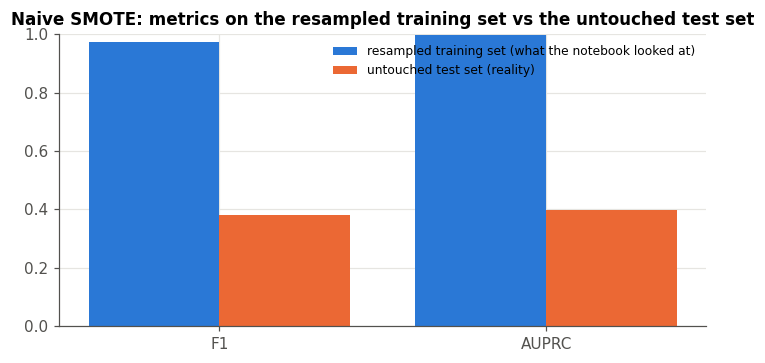

In [6]:
naive, _ = boosting.naive_smote_demo(X_train, y_train, X_test, y_test, n_trees)
P.plot_leakage_bars(naive, title="Naive SMOTE: metrics on the resampled training set vs the untouched test set");
naive.round(3)

## 4. Decision tree and random forest

Class-weighted trees tuned by grid search on average precision. The **reduced** random forest keeps only the encoded columns whose *out-of-fold* permutation importance exceeds 0.005 AUPRC (notebook 04 shows the ranking); the selection uses training folds only.

In [7]:
run("Decision tree", forest.build_decision_tree())
run("Random forest", forest.build_random_forest())

Decision tree                  AUPRC=0.180  F1=0.292  ROC AUC=0.685  threshold=0.79  (9s)


Random forest                  AUPRC=0.437  F1=0.333  ROC AUC=0.808  threshold=0.47  (55s)


In [8]:
from coffee_quality import interpret as I
perm = I.cv_permutation_importance(results["Random forest"].estimator.best_estimator_, X_train, y_train, n_repeats=10)
selected = perm.loc[perm["importance_mean"] > 0.005, "feature"].tolist()
print(len(selected), "columns kept:", selected)
run("Random forest (reduced)", forest.build_reduced_random_forest(selected))

14 columns kept: ['altitude_mean_meters', 'MacroArea_Africa', 'Processing.Method_Washed', 'Moisture', 'Processing.Method_Natural', 'Category.Two.Defects', 'Color_Unknown', 'Variety_Other', 'Moisture_missing', 'MacroArea_South America', 'MacroArea_Central/North America', 'Variety_Bourbon', 'Color_green', 'Variety_Unknown']


Random forest (reduced)        AUPRC=0.402  F1=0.324  ROC AUC=0.799  threshold=0.55  (51s)


## 5. Comparison

In [9]:
summary = E.summary_table(list(results.values()))
E.format_summary(list(results.values()))

,Threshold,Precision,Recall,F1,ROC AUC,AUPRC,OOF AUPRC
Model,,,,,,,
LogReg (unpenalised),0.75,0.421,0.381,"0.400 [0.19, 0.58]",0.742,"0.327 [0.15, 0.52]",0.301
LogReg (unpenalised + RFECV),0.62,0.263,0.476,"0.339 [0.17, 0.47]",0.743,"0.340 [0.15, 0.53]",0.263
LogReg L2,0.68,0.320,0.381,"0.348 [0.16, 0.51]",0.754,"0.322 [0.15, 0.51]",0.309
LogReg L1,0.63,0.276,0.381,"0.320 [0.14, 0.47]",0.767,"0.317 [0.14, 0.50]",0.299
XGBoost,0.48,0.281,0.429,"0.340 [0.15, 0.51]",0.784,"0.411 [0.20, 0.63]",0.338
XGBoost + feature eng.,0.67,0.368,0.333,"0.350 [0.12, 0.56]",0.791,"0.415 [0.20, 0.62]",0.345
XGBoost (grid search),0.70,0.600,0.286,"0.387 [0.13, 0.61]",0.765,"0.400 [0.19, 0.63]",0.377
XGBoost + SMOTE-NC,0.38,0.265,0.429,"0.327 [0.15, 0.48]",0.721,"0.412 [0.20, 0.63]",0.358
Decision tree,0.79,0.259,0.333,"0.292 [0.12, 0.45]",0.685,"0.180 [0.10, 0.35]",0.303


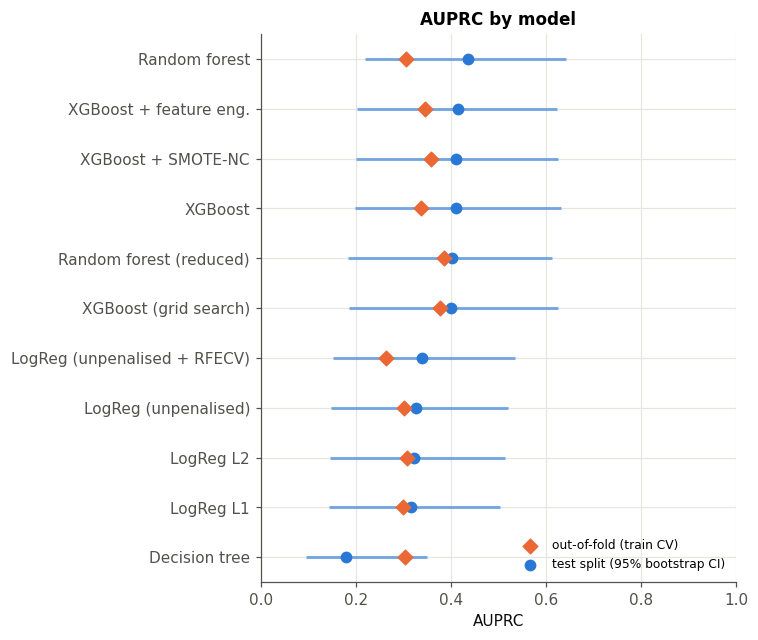

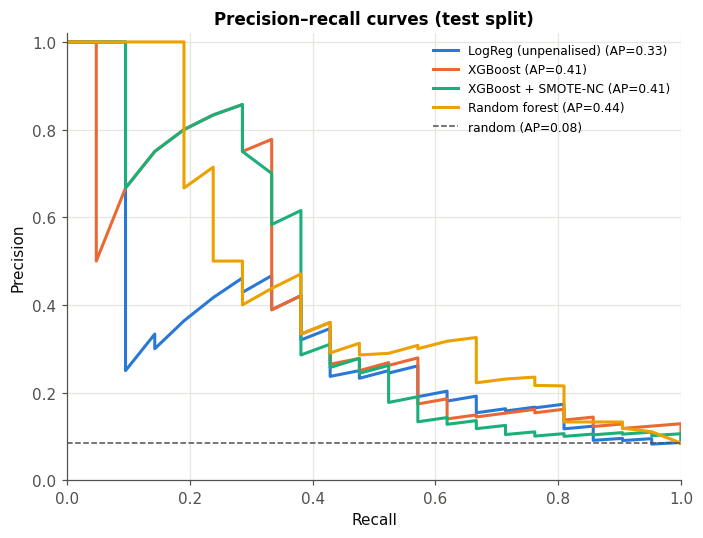

In [10]:
P.plot_metric_comparison(summary, "auprc");
P.plot_pr_curves([results[k] for k in ["LogReg (unpenalised)", "XGBoost", "XGBoost + SMOTE-NC", "Random forest"]]);

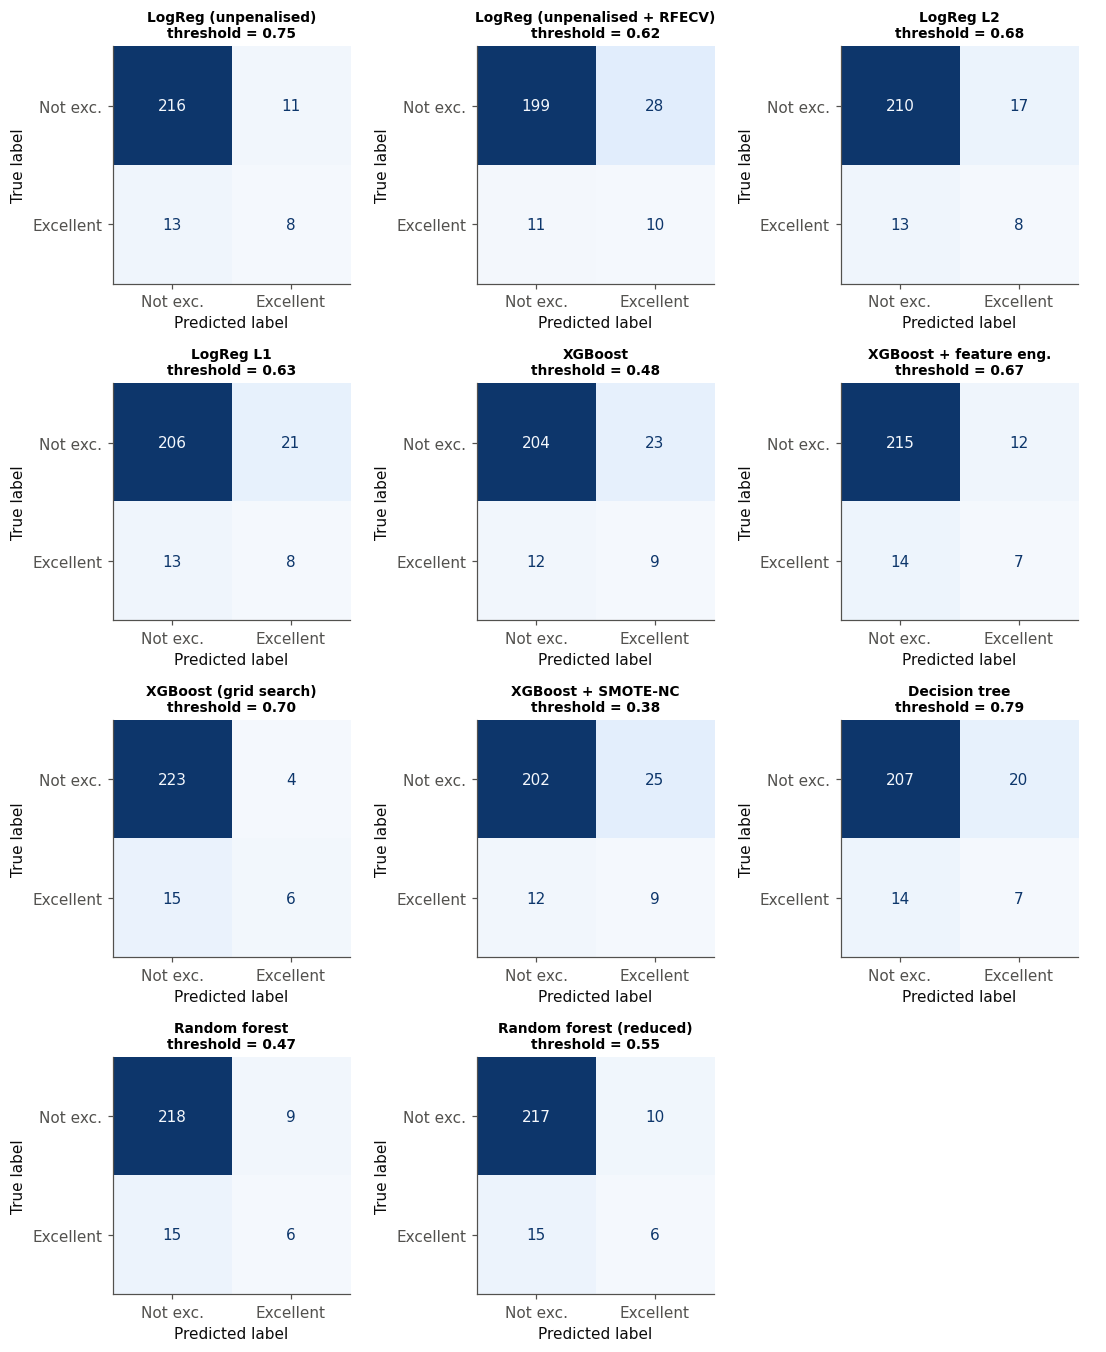

In [11]:
P.plot_confusion_matrices(list(results.values()));

### Reading the table

* Every model beats the random baseline (AUPRC = 0.08) by a wide margin: **the agronomic signal is real**.
* The tree ensembles (random forest, XGBoost in any flavour) reach an AUPRC around 0.40–0.44 on the test split and 0.34–0.38 out-of-fold; the logistic regressions sit around 0.30–0.34. The ensembles capture interactions (altitude × origin, moisture × processing) that a linear logit cannot.
* **None of the differences between the ensembles is statistically meaningful**: the bootstrap intervals (≈ ±0.2 AUPRC) overlap almost entirely, because 21 test positives are simply too few. Feature engineering, SMOTE-NC and the grid search each move the point estimate by a few hundredths — inside the noise.
* At the F1-optimal threshold the best models retrieve roughly 3–4 excellent lots out of 10 while being right about 3–4 times out of 10 when they flag one. Useful as a **screening** tool (which lots deserve a cupping slot first), not as a substitute for cupping.

## 6. Why the original numbers looked better

The team's first Random Forest reported F1 ≈ 0.62 and AUPRC ≈ 0.61. Part of the gap is a different sample (the old pipeline dropped lots whose altitude could not be imputed at region level), but most of it was **validation leakage**: the threshold was picked on the test labels and the feature selection used the test split. The first mistake alone is worth about +0.1 F1 on this data:

In [12]:
E.threshold_leakage_demo(results["Random forest"]).round(3)

,threshold,precision,recall,f1,auprc
threshold chosen on OOF train predictions (correct),0.467,0.400,0.286,0.333,0.437
threshold chosen on the test labels (leakage),0.120,0.326,0.667,0.438,0.437


AUPRC does not move — it does not depend on the threshold — which is exactly why it is the headline metric of this project.

Next: notebook 04 looks *inside* the models (coefficients, SHAP, permutation importance) to see which variables carry the signal.